# Spaceship Titanic — Exploratory Data Analysis
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Full EDA of the Spaceship Titanic Kaggle dataset — the project dataset for Weeks 6–8. No model training. Every finding directly informs a feature engineering decision in Week 6.

### Main goals:

- Audit shape, dtypes, and missing values across all columns.
- Understand the target distribution and key feature relationships.
- Parse the `Cabin` compound string into `Deck`, `CabinNum`, and `Side`.
- Analyse spending feature distributions and the CryoSleep interaction.
- Conclude with concrete Feature Engineering Decisions for Week 6.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Load Dataset

In [2]:
url = 'https://raw.githubusercontent.com/mohitkhyalia1/sos_2026/refs/heads/main/dataset/spaceship_titanic_train.csv'
df = pd.read_csv(url)
print(f'Shape: {df.shape}')
df.head()

Shape: (8693, 14)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## Data Overview

In [3]:
print(df.dtypes)
print()
print(df.describe())

PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.000000   8485.000000   8510.000000   
mean     28.827930    224.687617    458.077203    173.729169    311.138778   
std      14.489021    666.717663   1611.489240    604.696458   1136.705535   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      19.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      38.000000     47.000000     76.000000     27.000000     59.000000   
max      79.000000  14327

## Missing Value Audit

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df.to_string())

              Missing Count  Missing %
CryoSleep               217       2.50
ShoppingMall            208       2.39
VIP                     203       2.34
HomePlanet              201       2.31
Name                    200       2.30
Cabin                   199       2.29
VRDeck                  188       2.16
FoodCourt               183       2.11
Spa                     183       2.11
Destination             182       2.09
RoomService             181       2.08
Age                     179       2.06


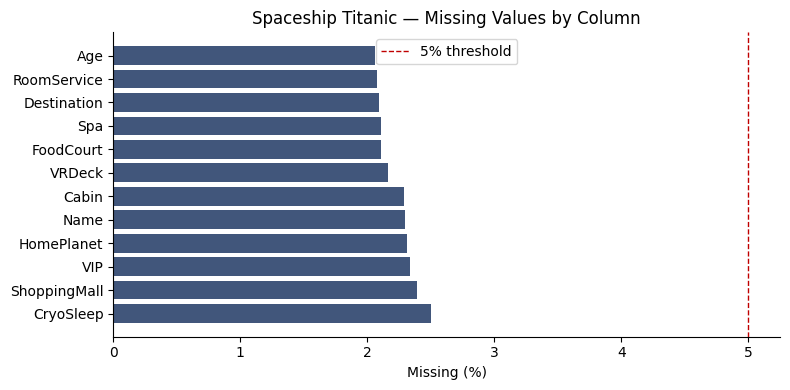

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(missing_df.index, missing_df['Missing %'], color='#1F3864', alpha=0.85)
ax.set_xlabel('Missing (%)')
ax.set_title('Spaceship Titanic — Missing Values by Column')
ax.axvline(5, color='#C00000', lw=1, linestyle='--', label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()

**Observation:**
Missing values are spread across almost every column at roughly 2–3%, suggesting the data was not collected for all passengers rather than systematic missingness. Median imputation for numeric columns and most-frequent imputation for categorical columns are appropriate strategies — these are exactly the SimpleImputer defaults used in the pipeline template from `machine_learning_pipelines.ipynb`.

## Target Distribution

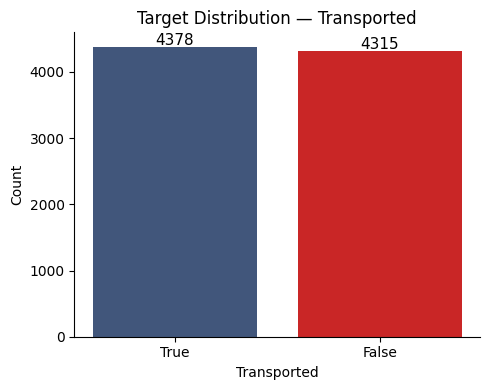

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['Transported'].value_counts()
ax.bar(counts.index.astype(str), counts.values,
       color=['#1F3864', '#C00000'], alpha=0.85)
ax.set_xlabel('Transported')
ax.set_ylabel('Count')
ax.set_title('Target Distribution — Transported')
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

**Observation:**
The target is nearly balanced (~50/50), so accuracy is a meaningful metric and no class-weighting or resampling is needed. This is a simpler situation than the imbalanced datasets from Week 2.

## Cabin Parsing

The `Cabin` column stores three pieces of information in the format `Deck/Number/Side`. Parsing it creates three usable features — exactly the pattern practised in `feature_engineering_for_spaceship_titanic.ipynb`.

In [7]:
df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)
df['CabinNum'] = pd.to_numeric(df['CabinNum'], errors='coerce')

print('Deck value counts:')
print(df['Deck'].value_counts())
print()
print('Side value counts:')
print(df['Side'].value_counts())

Deck value counts:
Deck
F    2794
G    2559
E     876
B     779
C     747
D     478
A     256
T       5
Name: count, dtype: int64

Side value counts:
Side
S    4288
P    4206
Name: count, dtype: int64


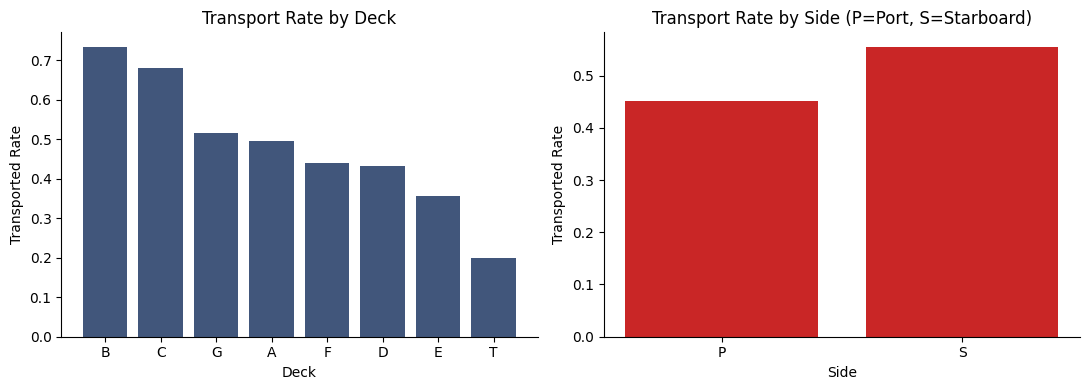

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

deck_transport = (df.groupby('Deck')['Transported']
                   .mean().sort_values(ascending=False))
axes[0].bar(deck_transport.index, deck_transport.values, color='#1F3864', alpha=0.85)
axes[0].set_xlabel('Deck')
axes[0].set_ylabel('Transported Rate')
axes[0].set_title('Transport Rate by Deck')

side_transport = df.groupby('Side')['Transported'].mean()
axes[1].bar(side_transport.index, side_transport.values, color='#C00000', alpha=0.85)
axes[1].set_xlabel('Side')
axes[1].set_ylabel('Transported Rate')
axes[1].set_title('Transport Rate by Side (P=Port, S=Starboard)')

plt.tight_layout()
plt.show()

**Observation:**
Transportation rate varies meaningfully by `Deck` (B and C show higher rates) and less so by `Side`. Keeping `Deck` as a separate one-hot encoded feature and `CabinNum` as a numeric feature is justified — the raw `Cabin` string alone cannot carry this signal to a model.

## Spending Feature Analysis

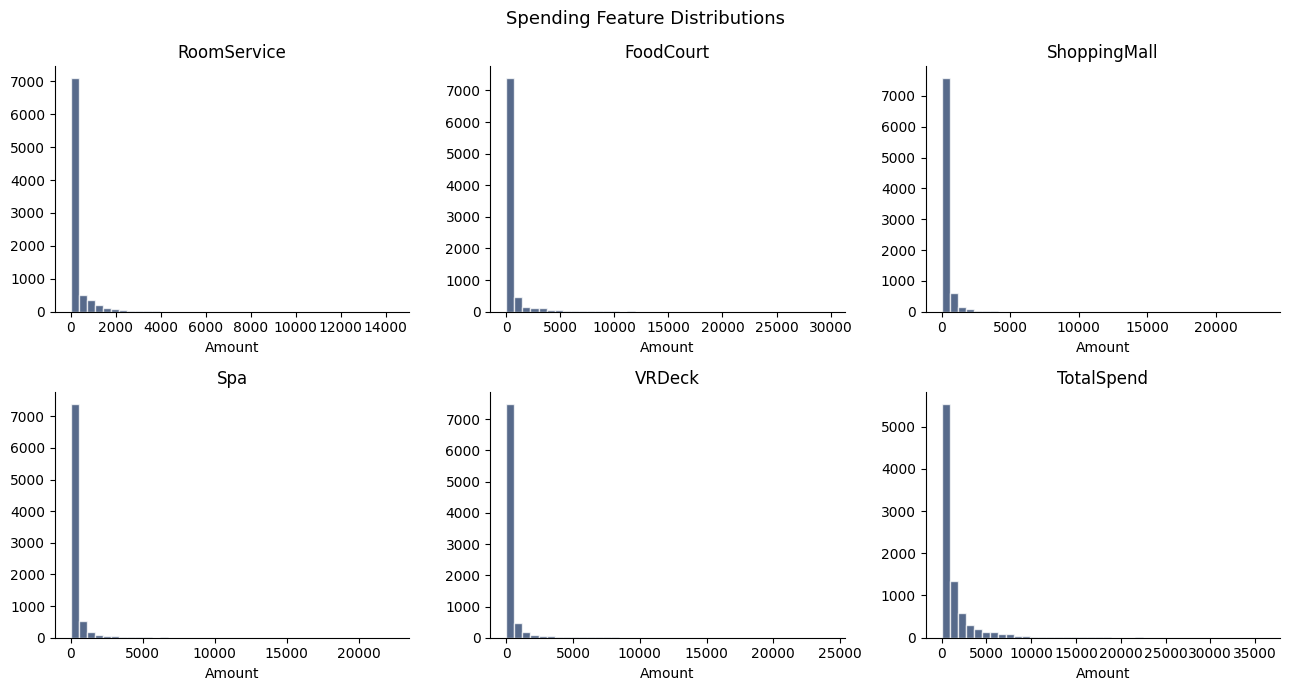

In [9]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df['TotalSpend'] = df[spend_cols].fillna(0).sum(axis=1)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()
for i, col in enumerate(spend_cols + ['TotalSpend']):
    axes[i].hist(df[col].dropna(), bins=40, color='#1F3864', alpha=0.75, edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Amount')
plt.suptitle('Spending Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

**Observation:**
All spending columns are right-skewed with a large spike at zero — many passengers spend nothing. `TotalSpend` aggregates the five columns into a single feature that may be more stable than individual columns for some models. A log-transform (`log1p`) would reduce the skew significantly.

## CryoSleep × Spending Interaction

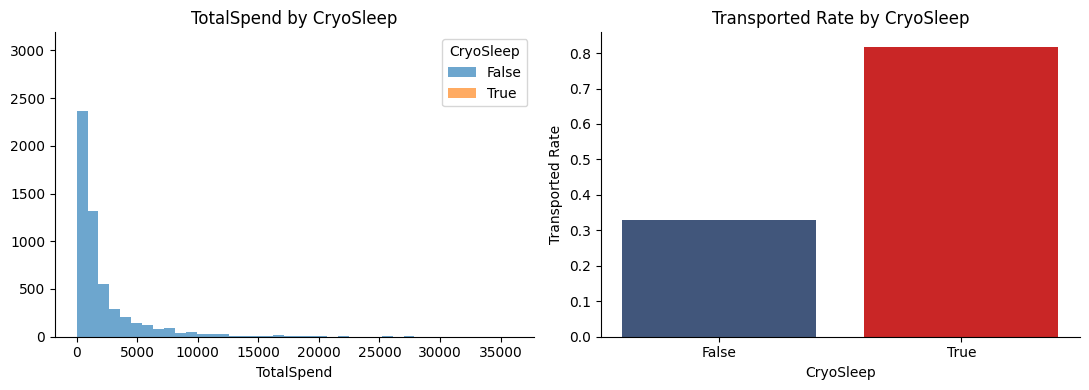

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# TotalSpend by CryoSleep status
for status, grp in df.groupby('CryoSleep'):
    axes[0].hist(grp['TotalSpend'].dropna(), bins=40, alpha=0.65, label=str(status))
axes[0].set_title('TotalSpend by CryoSleep')
axes[0].set_xlabel('TotalSpend')
axes[0].legend(title='CryoSleep')

# Transport rate by CryoSleep
ct = df.groupby('CryoSleep')['Transported'].mean()
axes[1].bar(ct.index.astype(str), ct.values, color=['#1F3864', '#C00000'], alpha=0.85)
axes[1].set_xlabel('CryoSleep')
axes[1].set_ylabel('Transported Rate')
axes[1].set_title('Transported Rate by CryoSleep')

plt.tight_layout()
plt.show()

**Observation:**
Passengers in cryosleep spend virtually nothing — confirming the interaction: `CryoSleep == True` implies all spending columns are zero or missing, and they are transported at a much higher rate (~80%). This interaction is the strongest signal in the dataset and can be explicitly engineered as `IsSpender = (TotalSpend > 0)`.

## Categorical Feature Distributions

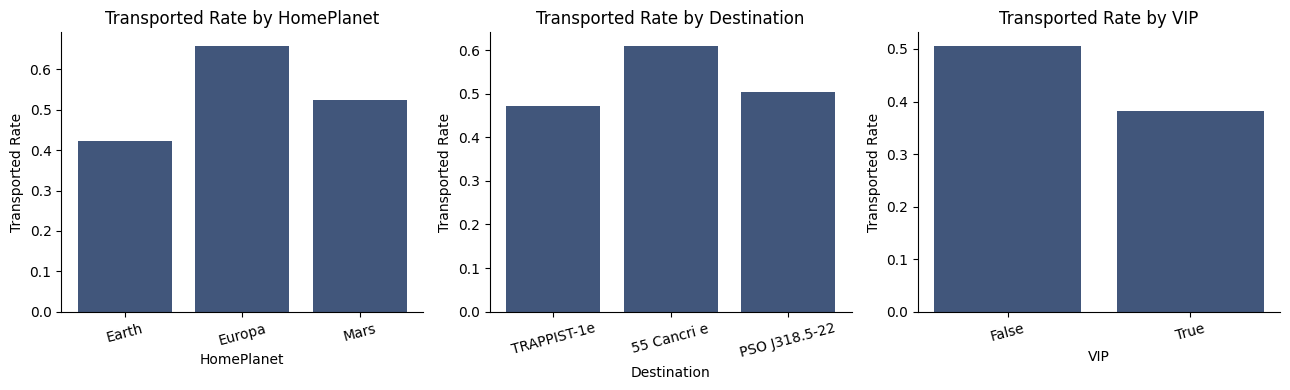

In [11]:
cat_cols = ['HomePlanet', 'Destination', 'VIP']
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    transport_rate = df.groupby(col)['Transported'].mean().reindex(order)
    ax.bar(transport_rate.index.astype(str), transport_rate.values,
           color='#1F3864', alpha=0.85)
    ax.set_title(f'Transported Rate by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Transported Rate')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Observation:**
`HomePlanet` shows meaningful variation — Europa passengers are transported at a substantially higher rate than Mars or Earth passengers. `Destination` also separates classes. Both should be one-hot encoded (as practised in `feature_engineering_for_spaceship_titanic.ipynb`) rather than label encoded, since neither has an ordinal relationship.

## Correlation Analysis

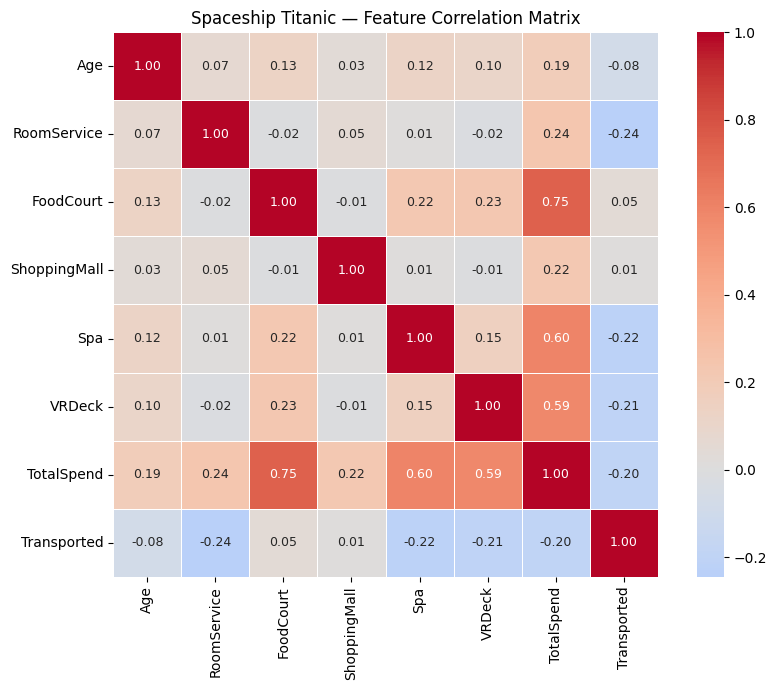

In [12]:
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend']
corr_df = df[numeric_cols + ['Transported']].copy()
corr_df['Transported'] = corr_df['Transported'].astype(float)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.4, ax=ax, annot_kws={'size': 9})
ax.set_title('Spaceship Titanic — Feature Correlation Matrix')
plt.tight_layout()
plt.show()

**Observation:**
The spending columns are moderately correlated with each other — suggesting `TotalSpend` captures most of their joint information. Correlation with `Transported` is low for individual spending columns but becomes stronger via the `CryoSleep` interaction identified above.

## Age Distribution

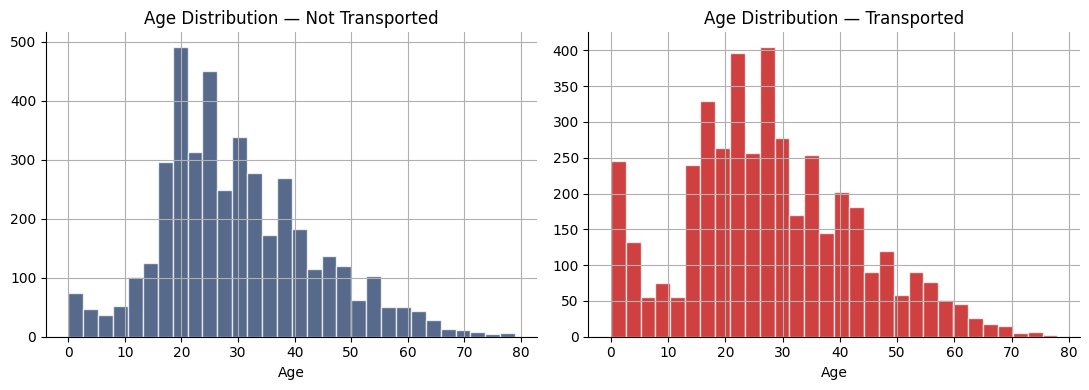

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for t_val, ax in zip([False, True], axes):
    label = 'Transported' if t_val else 'Not Transported'
    color = '#C00000' if t_val else '#1F3864'
    df[df['Transported'] == t_val]['Age'].dropna().hist(
        bins=30, ax=ax, color=color, alpha=0.75, edgecolor='white')
    ax.set_title(f'Age Distribution — {label}')
    ax.set_xlabel('Age')

plt.tight_layout()
plt.show()

**Observation:**
Younger passengers (under 10) are transported at a higher rate, suggesting an age interaction. An age-bin feature (`AgeGroup`) with bands for children, young adults, adults, and seniors may capture this step-wise pattern better than the raw continuous value.

## Feature Engineering Decisions for the Final Project

Based on the analysis above, the following preprocessing and feature engineering steps will be applied in Week 6:

| Decision | Justification |
|---|---|
| Parse `Cabin` → `Deck`, `CabinNum`, `Side` | Transport rate varies by Deck; string unusable directly |
| Drop raw `Cabin` and `PassengerId` columns | Replaced by parsed features; ID is non-informative |
| One-hot encode `HomePlanet`, `Destination`, `Deck`, `Side` | Unordered categoricals — OHE confirmed better than LE in `feature_engineering_for_spaceship_titanic.ipynb` |
| Median impute all numeric columns | ~2–3% missing, no systematic pattern |
| Most-frequent impute all categorical columns | Same reasoning |
| Create `TotalSpend = sum(spend_cols)` | Aggregates correlated features, stronger single signal |
| Create `IsSpender = (TotalSpend > 0)` | Captures CryoSleep interaction directly |
| Apply `log1p` to all spending columns and `TotalSpend` | Right-skewed distributions |
| Bin `Age` into `AgeGroup` | Step-wise relationship with target; children transported at higher rate |
| Standard-scale all numeric features | Required for Logistic Regression and SVM in the comparison |
| Wrap all steps in a Pipeline + ColumnTransformer | Prevents data leakage as practised in `machine_learning_pipelines.ipynb` |